# Practical Session 5 - Parallel Markov chains with multiprocessing and dask

Students (pair):
- [Gabriel Gozlan]([link](https://github.com/GabrielGozlan))
- [Rakel Ouakil]([link](https://github.com/RakelOuakil))


**Useful references for this lab**:

[1] `seaborn`: [official tutorial](https://seaborn.pydata.org/tutorial.html)

[2] `multiprocessing`: [documentation](https://docs.python.org/3/library/multiprocessing.html), [doc2](https://he-arc.github.io/livre-python/multiprocessing/index.html)

[3] `dask`: [documentation](http://numba.pydata.org/) 

## <a name="content">Contents</a>
- [Exercise 1: seaborn, a useful tool for data visualisation](#ex1)
- [Exercise 2: Simulating a discrete-time homogeneous Markov chain](#ex2)
- [Bonus: Parallel computing with Dask](#bonus)
---

In [1]:
%load_ext autoreload
%autoreload 2

## <a name="ex1">Exercise 1: seaborn, a useful tool for data visualisation</a> [(&#8593;)](#content)
 
The `seaborn` package can significantly enhance data and data analysis visualization. See the [tutorial page](https://seaborn.pydata.org/tutorial.html) for examples of effective predefined graphics. An example aimed at visualizing the empirical distributions of 9 realizations of a bivariate Gaussian random vector is reported below.

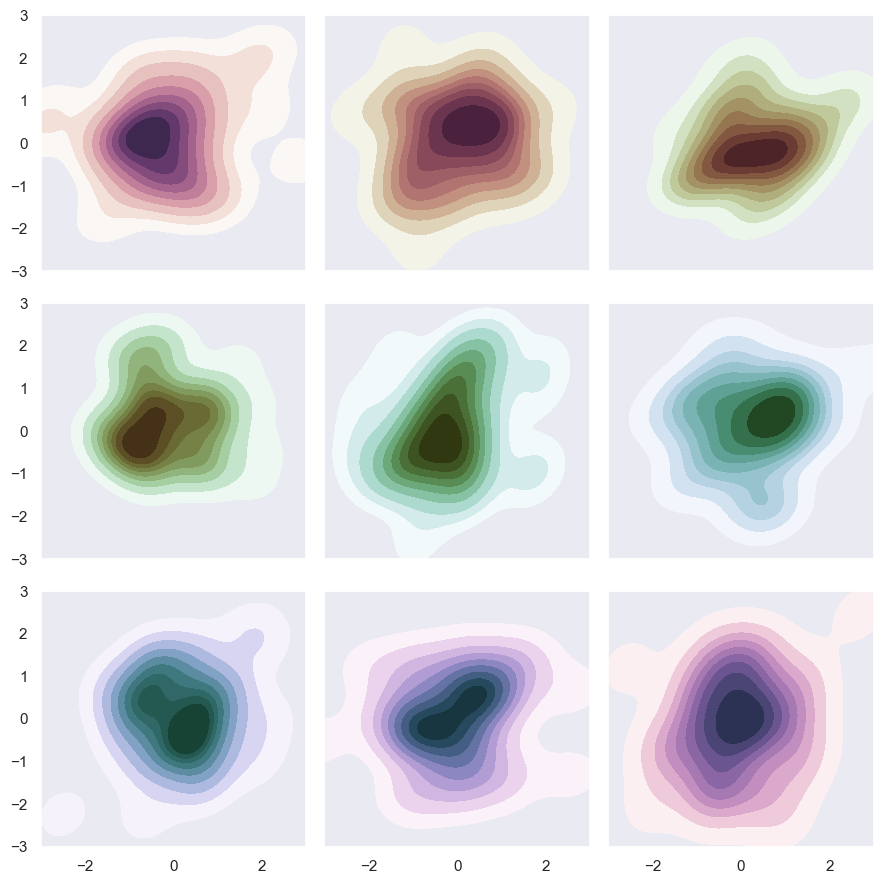

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(style="dark")
rng = np.random.default_rng(50)

# Set up the matplotlib figure
f, axes = plt.subplots(3, 3, figsize=(9, 9), sharex=True, sharey=True)

# Rotate the starting point around the cubehelix hue circle
for ax, s in zip(axes.flat, np.linspace(0, 3, 10)):

    # Create a cubehelix colormap to use with kdeplot
    cmap = sns.cubehelix_palette(start=s, light=1, as_cmap=True)

    # Generate and plot a random bivariate dataset
    x, y = rng.normal(size=(2, 50))
    sns.kdeplot(x=x, y=y, cmap=cmap, fill=True, cut=5, ax=ax)
    ax.set(xlim=(-3, 3), ylim=(-3, 3))

f.tight_layout()

1. Comment on the lines of codes related to the `seaborn` library to make their role explicit. More specifically comment on the KDE method.

**Answer:**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Configuration du style global des graphiques
# "dark" donne un fond sombre et des axes clairs$
sns.set(style="dark")

# Générateur aléatoire initialisé avec une seed fixe pour obtenir des résultats reproductibles
rng = np.random.default_rng(50)

# Création d'une figure matplotlib de 3x3 sous-graphiques
# sharex/sharey = True : toutes les figures partagent la même échelle d’axes
f, axes = plt.subplots(3, 3, figsize=(9, 9), sharex=True, sharey=True)

# Boucle sur chaque sous-graphe (axes.flat)
for ax, s in zip(axes.flat, np.linspace(0, 3, 10)):

    # Création d'une palette de couleurs cubehelix, adaptée pour les dégradés de densité
    # 'start=s' fait tourner la teinte autour du cercle des couleurs
    # 'light=1' rend les couleurs plus claires
    # 'as_cmap=True' indique qu’on crée une colormap utilisable par seaborn
    cmap = sns.cubehelix_palette(start=s, light=1, as_cmap=True)

    # Génération d’un échantillon aléatoire bivarié (x et y suivent une loi normale centrée réduite)
    x, y = rng.normal(size=(2, 50))

    # Tracé de la densité empirique 2D avec sns.kdeplot :
    # calcule une Kernel Density Estimation : une estimation lissée de la densité de probabilité
    # 'cmap' donne la palette de couleurs
    # 'fill=True' colore les zones de forte densité
    # 'cut=5' prolonge légèrement la zone de calcul au-delà des données
    # 'ax=ax' trace le graphique dans le sous-graphique correspondant

    #calcule la densité de probabilité conjointe de (x, y)  et colore les zones selon la densité (plus c’est foncé = plus de points)
    sns.kdeplot(x=x, y=y, cmap=cmap, fill=True, cut=5, ax=ax)


    # Fixe les limites des axes pour garder une même échelle sur tous les sous-graphiques
    ax.set(xlim=(-3, 3), ylim=(-3, 3))

# Ajuste automatiquement la disposition pour éviter que les sous-graphiques se chevauchent
f.tight_layout()


Dans cet exemple, la librairie seaborn est utilisé pour visualiser une distribution empirique de données simulées. La fonction sns.kdeplot() rerésente l'estimation de densité par noyau, c’est une technique statistique utilisée pour estimer la forme de la distribution de probabilité d’un ensemble de données. La KDE crée une courbe lissée qui approxime la densité de probabilité réelle.

2. For one of the realizations, take a look at the documentation of [`sns.jointplot`](https://seaborn.pydata.org/examples/joint_kde.html) to display both the 2-D empirical distribution of the data, and 1D histograms of their distribution along each axis. 

**Answer:**

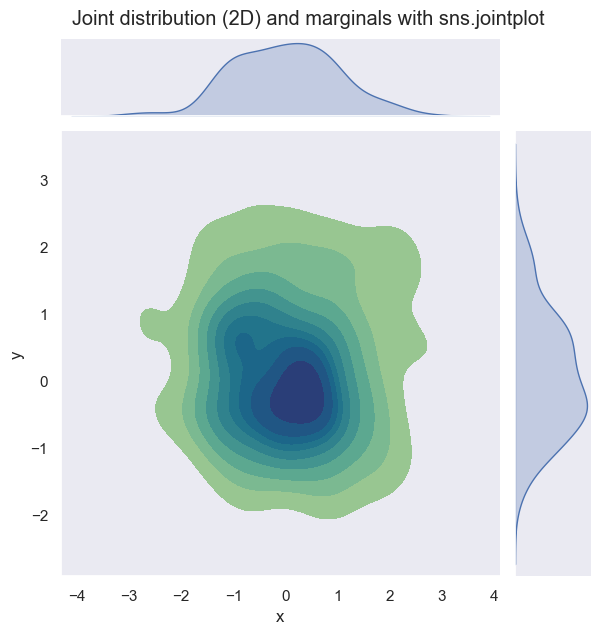

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Générateur aléatoire pour reproductibilité
rng = np.random.default_rng(50)

# Génération d'une seule réalisation d'un vecteur gaussien 2D
x, y = rng.normal(size=(2, 200))

# Visualisation de la distribution conjointe et des marginales
sns.jointplot(
    x=x, y=y,
    kind="kde",       # utilise la méthode Kernel Density Estimation
    fill=True,        # remplit les zones de densité
    cmap="crest",     # palette de couleurs
    thresh=0.05       # seuil pour afficher les contours
)
plt.xlabel("x")
plt.ylabel("y")
plt.suptitle("Joint distribution (2D) and marginals with sns.jointplot", y=1.02)
plt.show()


## <a name="ex2">Exercise 2: Simulating a discrete-time homogeneous Markov chain.</a> [(&#8593;)](#content)


Let ${(X_n)}_{n\geq 0}$ be a discrete-time homogeneous Markov chain with values over a finite ensemble $E=\{x_1,\dots,x_N\}$ identified to $\{1,\dots,N\}$. Consider $\boldsymbol{\rho} \in \Delta_N$, where $\Delta_N = \{\mathbf{x}\in\mathbb{R}^N \mid x_n \geq 0 \, \forall n \in \{1,\dotsc,N\} \text{ and } \sum_n x_n = 1 \}$ is the unit simplex in $\mathbb{R}^N$.

In the following, we consider the initial state of the chain $X_0$, following the discrete probability distribution:

$$
    \mathbb{P}(X_0 = k) = \rho_k, \qquad k \in \{1, \dots,  N\}.
$$
  
Let $\mathbf{A} = [a_{i,j}]_{i,j} \in \mathbb{R}^{N \times N}$ be the transition matrix of the chain, i.e.,

\begin{align*}
    &a_{i,j} = \mathbb{P}(X_{n+1} = j \mid X_{n} = i) \geq 0, \, \forall n \geq 0, \\
    &(\forall i \in \{1, \dotsc, N\}), \quad \sum_{j=1}^N a_{i,j} = 1.
\end{align*}
 
The chain is said to be homogeneous in that $\mathbf{A}$ does not depend from the time index $n$. Let $\tilde{a}_n$ represent the $n$-th row of $\mathbf{A}$. 

The trajectory of the chain can be simulated as follows:

>- Draw the discrete random variable $X_0$ with distribution $\boldsymbol{\rho}$;
>
>- For $q = 0$ to $n_{\text{iter}}-1$
>    - Draw the discrete random variable $X_{q+1}$ with distribution $\tilde{a}_{X_{q}}$;
>    
>- Return ${(X_q)}_{0 \leq q \leq n_{\text{iter}}}$.


<!-- If $X_n = k$, we know that $T$, the life time of the chain in the state $k$ obeys a geometric distribution with parameter $a_{kk}$. We also know that the probability of transition from k to $\ell\neq k$ is given by:

$$
    \mathbb{P}(X_{n+1}=\ell | X_n=k, \ell\neq k) = \frac{a_{k\ell}}{1-a_{kk}}.
$$

 ### One possible algorithm to simulate a Markov chain is therefore:

    a. generate the initial state $X_0$ according to the discrete law $\{\rho_1,\dots,\rho_N\}$.

    b. at instant $n$, knowing that $X_n=k$,

    i) determine the life time $T$ in state $X_n=k$ by simulating a geometrical variable with parameter $a_{kk}$. As a consequence $X_n = \dots = X_{n+T} = k$. When $T=0$, we simply still have $X_n=k$.

    ii) determine next transition instant $n+T$, and determine the next state by using the probabilities of transition. -->

1. Implement the above algorithm in a function `X = markov(rho,A,nmax,rng)` with:
     - `rho`: law of the initial state (nonnegative vector of size $N$, summing to 1),
     - `A`: transition matrix (of size $N\times N$) 
     - `nmax`: number of time steps,
     - `rng`: random number generator
     - `X`: trajectory of the chain.
     
In particular, check the input parameters `A` and `rho` make sense by adding appropriate assertions (or raising exceptions).
   - Examples : **transition matrix `A` should be square** ; **expected `A` to be a stochastic matrix** ; **verify if the size of `A` and `rho` are consistent** ; **verify if `rho` is in the unit simplex**
     - `np.allclose`, `np.isclose` and `np.all` could be useful

> Hints:
> - the function `np.random.choice` can be useful to draw discrete random variables.
> - use `states = np.arange(N)` to create the the labels of the states (from $0$ up to $N-1$)

Here is an example of execution : 
![alternatvie text](img/For_CourseM.png)

**Answer:**

In [36]:
import numpy as np
def markov(rho, A, nmax, rng):
    # Verifions la compatibilité des données

    A = np.array(A)
    rho = np.array(rho)
    assert A.shape[0] == A.shape[1], "La matrice n'est pas carrée"
    assert np.allclose(A.sum(axis=1),1), "A n'est pas une matrice stochastique"
    assert A.shape[0] == rho.shape[0], "A et rho ne sont pas compatibles"
    assert np.isclose(rho.sum(), 1), "Rho ne somme pas à 1"
    assert (np.all(A >= 0) and np.all(rho >= 0)), "Il y a des valeurs négatives parmi rho ou A"

    #Algorithme markov
    states = np.arange(A.shape[0])

    X = np.zeros(nmax, dtype=int)   # initialiser le tableau des états
    X0 = rng.choice(states,  p= rho) # tirage aléatoire d’un état selon la distribution rho
    X[0] = X0                       # état initial

    for i in range(1,nmax):
        X[i]=rng.choice(states, p=A[X[i-1]])

    return X


In [61]:
#exemple d'application

rng = np.random.default_rng(0)

rho = [0.2, 0.8]       # commence aléatoirement dans 0 ou 1
A = [[0.9, 0.1],        # si on est en 0 : 90% de rester, 10% d'aller à 1
     [0.5, 0.5]]        # si on est en 1 : 50% de rester, 50% de revenir à 0

X = markov(rho, A, nmax=30, rng=rng)
print("Trajectoire :", X)


Trajectoire : [1 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]


2. Set the random number generator to a known state. Make a few simulations using simple transition matrices (*i.e.*, taking any nonnegative matrix $A=(a_{i,j})$ such that its lines sum to 1) and display the trajectory of the chains.

**Answer:**

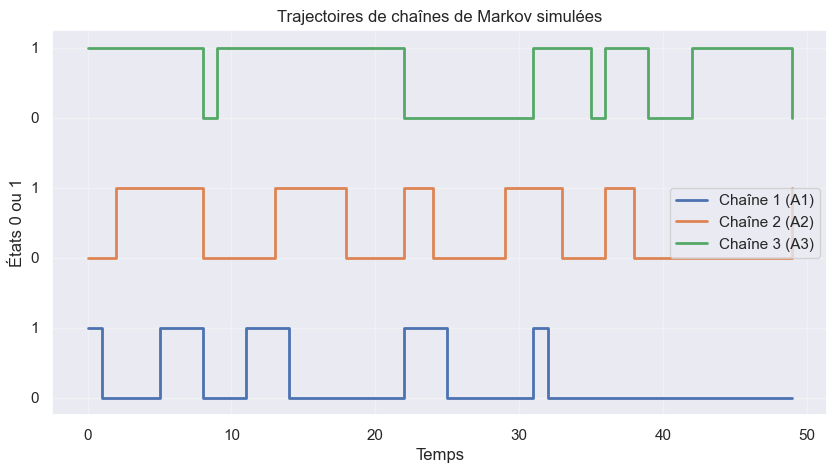

In [65]:
import matplotlib.pyplot as plt

# Fixer rng
rng = np.random.default_rng(42)

# Exemples de matrices de transition simples
A1 = [[0.9, 0.1],
      [0.5, 0.5]]

A2 = [[0.7, 0.3],
      [0.2, 0.8]]

A3 = [[0.6, 0.4],
      [0.1, 0.9]]

# Loi initiale : 50% de chance de commencer dans chaque état
rho = [0.5, 0.5]

# Longueur de la trajectoire
nmax = 50

# Simulation de plusieurs chaînes markov()
X1 = markov(rho, A1, nmax, rng)
X2 = markov(rho, A2, nmax, rng)
X3 = markov(rho, A3, nmax, rng)

# Affichage des trajectoires

plt.figure(figsize=(10, 5))

# décalage vertical pour séparer les chaînes visuellement
plt.step(range(nmax), X1 + 0, where="post", label="Chaîne 1 (A1)", linewidth=2)
plt.step(range(nmax), X2 + 2, where="post", label="Chaîne 2 (A2)", linewidth=2)
plt.step(range(nmax), X3 + 4, where="post", label="Chaîne 3 (A3)", linewidth=2)

# Décorations
plt.yticks([0, 1, 2, 3, 4, 5], ["0", "1", "0", "1", "0", "1"])
plt.xlabel("Temps")
plt.ylabel("États 0 ou 1")
plt.title("Trajectoires de chaînes de Markov simulées")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3. Explore the potential of the [`multiprocessing` package](https://docs.python.org/3/library/multiprocessing.html) to simulate several Markov chains in parallel.

> Hint: the `mutiprocessing.Pool.starmap` or `mutiprocessing.Pool.starmap_async` methods could be useful.

**Answer:**

In [ ]:
import numpy as np
import multiprocessing as mp
from time import time


def simulate_chain(rho, A, nmax, seed):
    rng = np.random.default_rng(seed)
    return markov(rho, A, nmax, rng)

# exemple
rho = [0.5, 0.5]
A = [[0.9, 0.1],
     [0.3, 0.7]]
nmax = 100_000
n_chains = 8
seeds = np.arange(n_chains)

# version séquentielle
t0 = time()
for s in seeds:
    simulate_chain(rho, A, nmax, s)
t1 = time()

# version parallèle
t2 = time()
with mp.Pool(processes=n_chains) as pool:
    pool.map(simulate_chain, [(rho, A, nmax, s) for s in seeds])
t3 = time()

print(f"Temps séquentiel : {t1 - t0:.3f} s")
print(f"Temps parallèle  : {t3 - t2:.3f} s")
print(f"Gain : x{(t1 - t0)/(t3 - t2):.2f}")

4. [Bonus] Generate Markov chains in parallel with the [`dask`](https://docs.dask.org/en/latest/futures.html) library, which offers more general parallelization functionalities (with, for instance, the use of [`Futures`](https://docs.dask.org/en/stable/futures.html), see tutorial [here](https://tutorial.dask.org/05_futures.html)). A useful example is provided [here](https://stackoverflow.com/questions/41471248/how-to-efficiently-submit-tasks-with-large-arguments-in-dask-distributed). Note that `dask` is much more versatile and powerful than `multiprocessing`, and can be useful to scale algorithms over multiple cores and/or computing nodes.

**Answer:**

In [ ]:
# your code

## <a name="bonus">Bonus: Parallel computing with Dask</a> [(&#8593;)](#content)

1. Take a look at the [`dask.array` documentation](https://docs.dask.org/en/stable/array-best-practices.html) and the associate [tutorial](https://tutorial.dask.org/02_array.html). Apply some of the functions introduced herein and in the [documentation](https://docs.dask.org/en/stable/array-best-practices.html) to parallelize the computation of the total variation investigated during session 2. Note that you can combine `dask` and `numba` to obtain an overall more efficient implementation. Note that timing can be worse than Numpy (`dask.array` is more specifically interesting when the data do no fit in memory).

2. Take a look at the [`dask.delayed` tutorial](https://tutorial.dask.org/03_dask.delayed.html), and go through some of the examples provided. [Best practices with the `dask.delayed` interface](https://docs.dask.org/en/stable/delayed-best-practices.html) are summarized in the documentation.

> **Remark**: an alternative to Dask: the [Ray](https://docs.ray.io/en/latest/) library.

**Answer:**

In [ ]:
# your code